# InvA / AFinal matrix mismatch artifacts

This notebook isolates one question: if we form SPEN-like data with `AFinal` and reconstruct with `InvA`, where do the residual artifacts come from?

If `InvA` were an exact inverse, `InvA @ AFinal` would be the identity matrix. In this implementation `InvA` is a Gaussian-weighted adjoint, so the product is a blur/leakage operator instead of a perfect identity. We visualize:

1. `image -> AFinal -> InvA`.
2. `AFinal`, `InvA`, and `InvA @ AFinal`.
3. The identity mismatch `(InvA @ AFinal - I)` and whether its predicted artifact appears in the same pixels as the measured round-trip artifact.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

torch.set_grad_enabled(False)


def find_spenpy_repo() -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / 'spenpy'):
            if (candidate / 'spenpy/data/brain.png').exists() and (candidate / 'spenpy/spen.py').exists():
                return candidate
    fallback = Path('/home/data1/musong/workspace/python/spen_recons/spenpy')
    if (fallback / 'spenpy/data/brain.png').exists():
        return fallback
    raise FileNotFoundError('Could not locate the local spenpy repository')


SPENPY_REPO = find_spenpy_repo()
if str(SPENPY_REPO) not in sys.path:
    sys.path.insert(0, str(SPENPY_REPO))

from spenpy.spen import spen


def pil_to_float_tensor(path: Path) -> torch.Tensor:
    image = Image.open(path).convert('L')
    data = torch.frombuffer(bytearray(image.tobytes()), dtype=torch.uint8).to(torch.float32)
    return data.reshape(image.height, image.width) / 255.0


def robust_abs01(value: torch.Tensor, percentile: float = 99.5) -> torch.Tensor:
    value = value.abs() if torch.is_complex(value) else value.float().abs()
    value = value.to(torch.float32)
    positive = value[value > 0]
    if positive.numel() == 0:
        scale = torch.tensor(1.0, dtype=value.dtype, device=value.device)
    else:
        scale = torch.quantile(positive, percentile / 100.0).clamp_min(1e-8)
    return torch.clamp(value / scale, 0.0, 1.0)


def fit_complex_gain(source: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    denom = (source.conj() * source).sum().real.clamp_min(1e-12)
    return (source.conj() * target).sum() / denom


def show_image(ax, value, title, cmap='gray', vmin=None, vmax=None, colorbar=False):
    image = value.detach().cpu() if isinstance(value, torch.Tensor) else value
    im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    if colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


def pearson_corr(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    a = a.reshape(-1).float()
    b = b.reshape(-1).float()
    a = a - a.mean()
    b = b - b.mean()
    denom = torch.linalg.vector_norm(a) * torch.linalg.vector_norm(b)
    return (a * b).sum() / denom.clamp_min(1e-12)


def top_fraction_mask(value: torch.Tensor, fraction: float = 0.05) -> torch.Tensor:
    flat = value.reshape(-1)
    k = max(1, round(flat.numel() * fraction))
    threshold = torch.topk(flat, k).values[-1]
    return value >= threshold


def dice_score(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    a = a.bool()
    b = b.bool()
    denom = a.sum() + b.sum()
    if denom == 0:
        return torch.tensor(1.0)
    return 2.0 * (a & b).sum().float() / denom.float()


print('SPENPy repo:', SPENPY_REPO)


SPENPy repo: /home/data1/musong/workspace/python/spenpy


## 1. Load an image and the SPEN matrices

We use the same `brain.png` image as the other simulation demos, resize it to the matrix size, then obtain `InvA` and `AFinal` from the scanner-like profile. No phase corruption or noise is used here: this is only the matrix round trip.


config  : /home/data1/musong/workspace/python/spenpy/spenpy/configs/scanner_like.yaml
image   : (256, 256) -> (96, 96)
InvA    : (96, 96) torch.complex64
AFinal  : (96, 96) torch.complex64


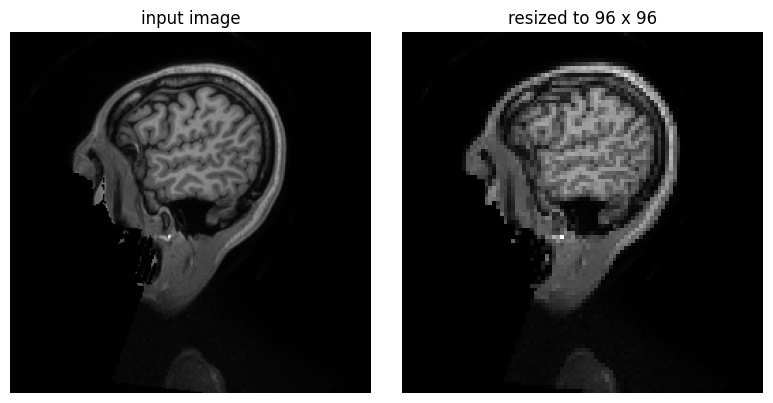

In [2]:
img_path = SPENPY_REPO / 'spenpy/data/brain.png'
config_path = SPENPY_REPO / 'spenpy/configs/scanner_like.yaml'

img = pil_to_float_tensor(img_path)
sim = spen.from_yaml(config_path, seed=0)
InvA, AFinal = sim.get_InvA()
InvA = InvA.to(torch.complex64)
AFinal = AFinal.to(torch.complex64)

matrix_size = AFinal.shape[0]
img_model = F.interpolate(
    img[None, None],
    size=(matrix_size, matrix_size),
    mode='bilinear',
    align_corners=False,
)[0, 0]
img_complex = img_model.to(torch.complex64).unsqueeze(0)

print('config  :', config_path)
print('image   :', tuple(img.shape), '->', tuple(img_model.shape))
print('InvA    :', tuple(InvA.shape), InvA.dtype)
print('AFinal  :', tuple(AFinal.shape), AFinal.dtype)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
show_image(ax[0], img, 'input image')
show_image(ax[1], img_model, f'resized to {matrix_size} x {matrix_size}')
plt.tight_layout()


## 2. How `InvA` reconstructs an `AFinal` encoded image

`AFinal` maps the image into the SPEN low-resolution encoded representation along PE. Reconstruction is then one matrix multiply with `InvA` along the same dimension.

The raw adjoint has an arbitrary global scale, so before measuring the residual we fit one complex gain that best matches the reconstruction to the reference. The residual map below is therefore the spatial artifact caused by using the weighted adjoint instead of a true inverse.


best-fit complex gain applied to InvA output: 118.5+0.5069j
round-trip NRMSE: 0.1022
magnitude Pearson correlation: 0.994384
max absolute artifact: 1.0841e-01


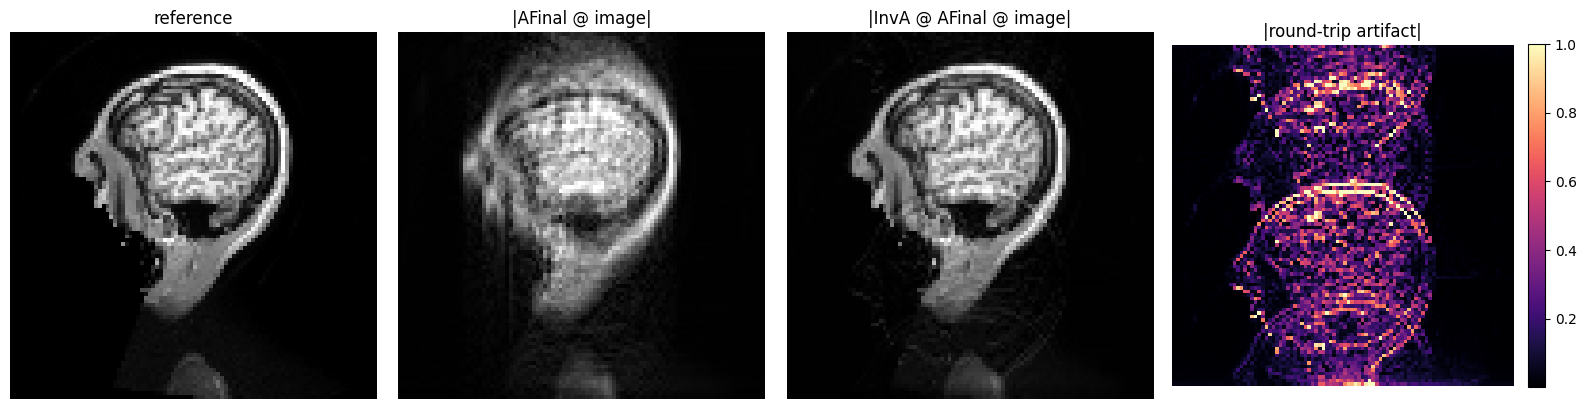

In [3]:
degraded = torch.matmul(AFinal, img_complex)
recon_raw = torch.matmul(InvA, degraded)
recon_gain = fit_complex_gain(recon_raw, img_complex)
recon = recon_gain * recon_raw
roundtrip_error = recon - img_complex

ref_mag = img_model.abs()
recon_mag = recon[0].abs()
error_mag = roundtrip_error[0].abs()
nrmse = torch.linalg.vector_norm(error_mag) / torch.linalg.vector_norm(ref_mag).clamp_min(1e-12)
corr = pearson_corr(ref_mag, recon_mag)

print(f'best-fit complex gain applied to InvA output: {recon_gain.item():.4g}')
print(f'round-trip NRMSE: {nrmse.item():.4f}')
print(f'magnitude Pearson correlation: {corr.item():.6f}')
print(f'max absolute artifact: {error_mag.max().item():.4e}')

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
show_image(ax[0], robust_abs01(img_model), 'reference')
show_image(ax[1], robust_abs01(degraded[0]), '|AFinal @ image|')
show_image(ax[2], robust_abs01(recon[0]), '|InvA @ AFinal @ image|')
show_image(ax[3], robust_abs01(error_mag, 99.0), '|round-trip artifact|', cmap='magma', colorbar=True)
plt.tight_layout()


## 3. Visualize `AFinal`, `InvA`, and their product

The important diagnostic is the product `M = InvA @ AFinal`. A perfect inverse would give `M = I`. The panel `|M - I|` shows the rows/columns where energy leaks away from the ideal identity operator.


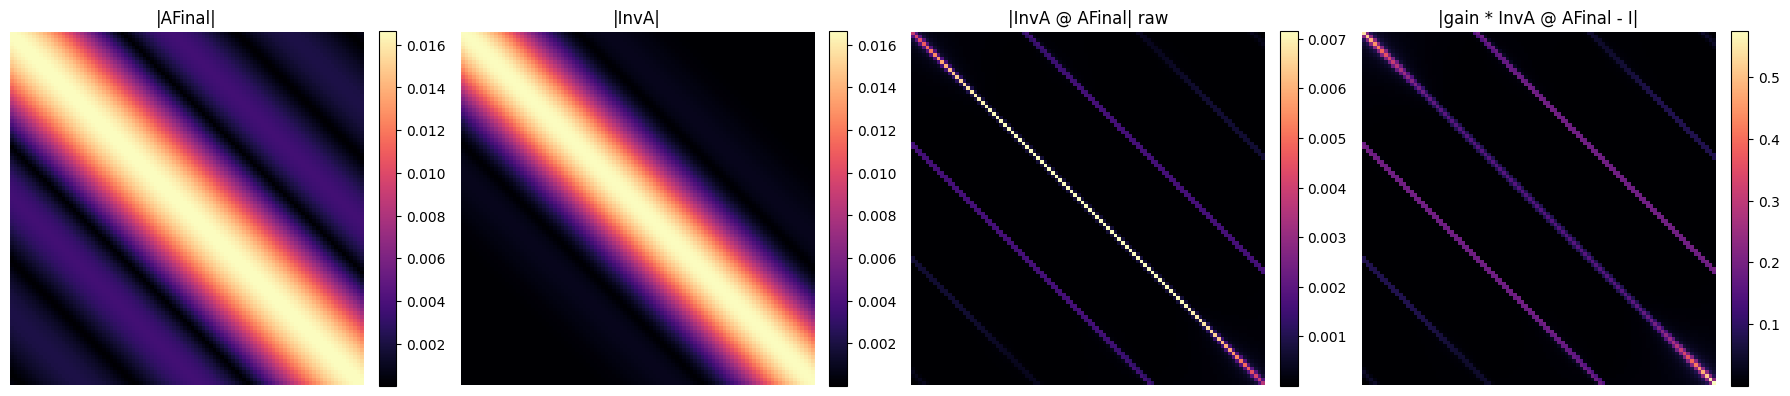

In [10]:
M_raw = torch.matmul(InvA, AFinal)
M = recon_gain * M_raw
I = torch.eye(M_raw.shape[0], dtype=M_raw.dtype, device=M_raw.device)
M_minus_I = M - I

diag_raw = torch.diagonal(M_raw)
diag = torch.diagonal(M)
offdiag = M.clone()
offdiag[torch.arange(M.shape[0]), torch.arange(M.shape[0])] = 0

fig, ax = plt.subplots(1, 4, figsize=(18, 4.4))
show_image(ax[0], AFinal.abs(), '|AFinal|', cmap='magma', colorbar=True)
show_image(ax[1], InvA.abs(), '|InvA|', cmap='magma', colorbar=True)
show_image(ax[2], M_raw.abs(), '|InvA @ AFinal| raw', cmap='magma', colorbar=True)
show_image(ax[3], M_minus_I.abs(), '|gain * InvA @ AFinal - I|', cmap='magma', colorbar=True)
plt.tight_layout()


## 4. Row profiles of the identity mismatch

Each row of the gain-matched `InvA @ AFinal` product acts like a point-spread function along PE. A perfect identity would have one value of 1 at the row index and zeros elsewhere. The side lobes are exactly the leakage that creates structured residuals after reconstruction.


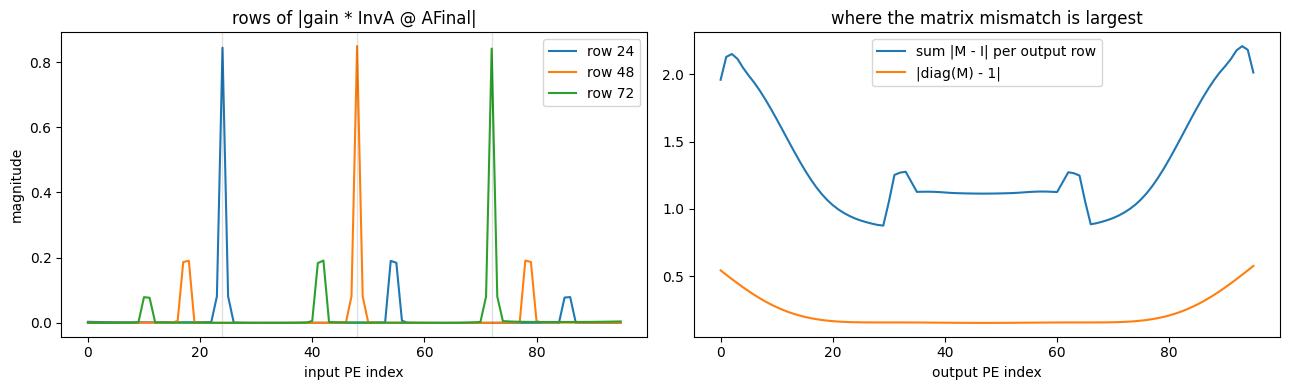

In [5]:
n = M.shape[0]
rows = [n // 4, n // 2, 3 * n // 4]
row_leakage = M_minus_I.abs().sum(dim=1)
diag_error = (diag - 1).abs()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for row in rows:
    ax[0].plot(M[row].abs().detach().cpu(), label=f'row {row}')
    ax[0].axvline(row, color='k', alpha=0.12, linewidth=1)
ax[0].set_title('rows of |gain * InvA @ AFinal|')
ax[0].set_xlabel('input PE index')
ax[0].set_ylabel('magnitude')
ax[0].legend()

ax[1].plot(row_leakage.detach().cpu(), label='sum |M - I| per output row')
ax[1].plot(diag_error.detach().cpu(), label='|diag(M) - 1|')
ax[1].set_title('where the matrix mismatch is largest')
ax[1].set_xlabel('output PE index')
ax[1].legend()
plt.tight_layout()


## 5. Do the artifacts appear in the same place?

For this controlled round trip, yes. The measured artifact is

`gain * InvA @ AFinal @ image - image`

and the matrix-predicted artifact is

`(gain * InvA @ AFinal - I) @ image`.

Those two expressions are algebraically identical. The cell below verifies this numerically, then shows the measured artifact, the predicted artifact, their product, their absolute disagreement, and a top-5-percent artifact mask overlay.


max |predicted - actual|: 3.2115e-07
artifact magnitude Pearson correlation: 1.000000
top 5 percent artifact mask Dice: 1.000000


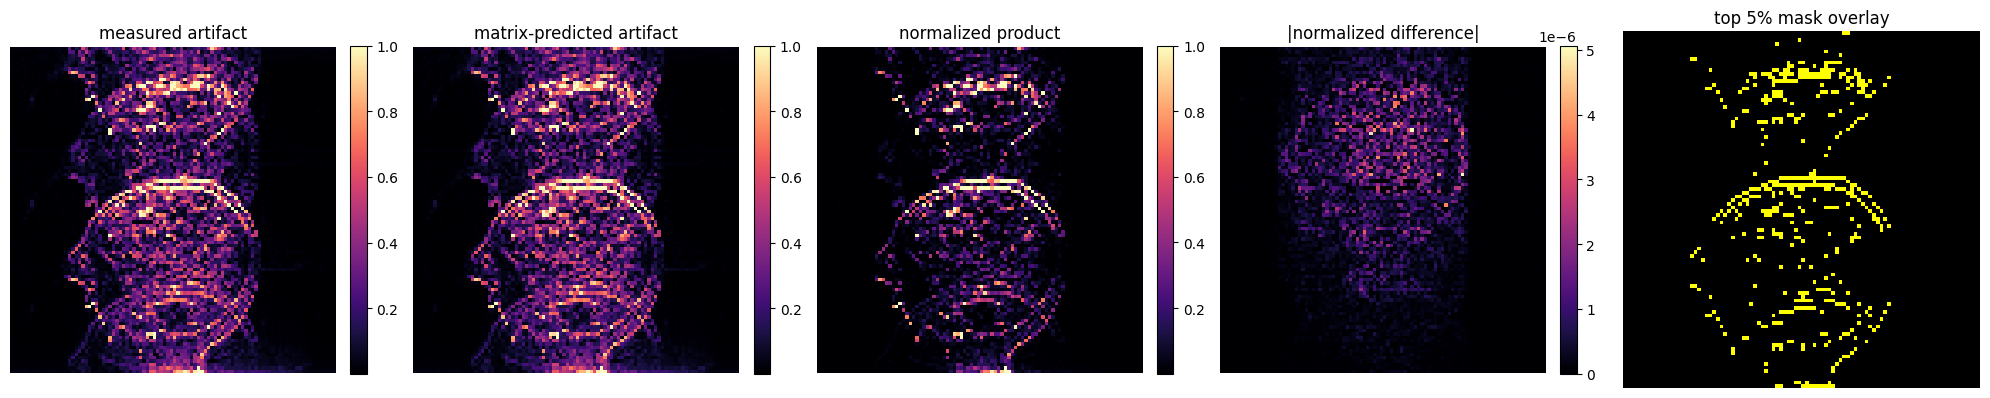

In [6]:
predicted_error = torch.matmul(M_minus_I, img_complex)
actual_error = roundtrip_error

actual_mag = actual_error[0].abs()
pred_mag = predicted_error[0].abs()
actual_norm = robust_abs01(actual_mag, 99.0)
pred_norm = robust_abs01(pred_mag, 99.0)
product_map = actual_norm * pred_norm
disagreement = (actual_norm - pred_norm).abs()

actual_mask = top_fraction_mask(actual_mag, 0.05)
pred_mask = top_fraction_mask(pred_mag, 0.05)
mask_overlay = torch.zeros((*actual_mask.shape, 3), dtype=torch.float32)
mask_overlay[..., 0] = actual_mask.float()
mask_overlay[..., 1] = pred_mask.float()

residual = (predicted_error - actual_error).abs().max()
artifact_corr = pearson_corr(actual_mag, pred_mag)
artifact_dice = dice_score(actual_mask, pred_mask)

print(f'max |predicted - actual|: {residual.item():.4e}')
print(f'artifact magnitude Pearson correlation: {artifact_corr.item():.6f}')
print(f'top 5 percent artifact mask Dice: {artifact_dice.item():.6f}')

fig, ax = plt.subplots(1, 5, figsize=(20, 4.2))
show_image(ax[0], actual_norm, 'measured artifact', cmap='magma', colorbar=True)
show_image(ax[1], pred_norm, 'matrix-predicted artifact', cmap='magma', colorbar=True)
show_image(ax[2], product_map, 'normalized product', cmap='magma', colorbar=True)
show_image(ax[3], disagreement, '|normalized difference|', cmap='magma', colorbar=True)
ax[4].imshow(mask_overlay.detach().cpu())
ax[4].set_title('top 5% mask overlay')
ax[4].axis('off')
plt.tight_layout()


## Reading the result

In the clean `AFinal -> InvA` experiment, the predicted and measured artifact locations should match up to floating-point error. If later cells add phase error, noise, trajectory shifts, or a bad phase estimate before applying `InvA`, those extra terms are no longer explained by `InvA @ AFinal - I` alone, so their artifacts can move or grow in different places.
